# Large Language Model (LLM)


This notebook file is mainly generated by **ChatGPT 5.1 and Claude**. It demonstrates how to use LLM interactive in a Jupyter notebook file.

## 1. Simple tiny language model

To install the interface to run the trained language models. You need to install `langchain_community`

`langchain_community` is the community-maintained integration package for LangChain.
It contains connectors for models, vector databases, tools, and LLM backends such as LlamaCpp, HuggingFace, etc.

Here is how to install it.

In [ ]:
# !pip install langchain_community
# !pip install langchain

Next, you can download some pre-trained language models from this website. After you download the model data, place it in the same folder to your notebook file or include the path to where the model is.

#### https://huggingface.co/

Here, we use a pretrained language model `tinyllama-1.1b-chat-v1.0.Q2_K.gguf` for demonstration. This tiny model is free to access. 

The cell below is the demonstration of calling Llama. 

>Llama (pronounced “lah-mah”) is a family of open-source large language models (LLMs) created by Meta (Facebook).
>They are similar in purpose to GPT models, but fully downloadable and runnable on your own computer (CPU/GPU), even laptops.

In [ ]:
from langchain_community.llms import LlamaCpp
import sys

model_path = "/Users/huichiayu/Work/MSE590400/Day28/models/tinyllama-1.1b-chat-v1.0.Q2_K.gguf"

llm = LlamaCpp(
    model_path=model_path,
    n_ctx=2048,
    n_gpu_layers=0,
    verbose=False,
    use_mmap=False,
    temperature=0.1,
    top_p=0.9,
    max_tokens=256,
    stop=["Q:", "\nQ:", "Question:", "\n\n"],  # This stops the unwanted continuation
)

system_prompt = (
    "You are a concise, helpful AI assistant. "
    "Answer user questions directly in 2-3 sentences."
)

print("Chat started! (Type 'stop' to exit)\n")

while True:
    question = input("You: ")
    if question.strip().lower() == "stop":
        print("Goodbye!")
        sys.exit(0)
    
    prompt = f"{system_prompt}\n\nQuestion: {question}\nAnswer:"
    output = llm.invoke(prompt)
    print(f"Assistant: {output.strip()}\n")

---
## 2. Meta llama 3.2 model. 

Here, we use a pretrained meta-llama 3.2 model for further demonstration. 

You can download the model to your local directory. However, before that you need to sign-up a huggingface account to get access to the model repository. You will also need to log-in before dowloadning.

* In your terminal (or in a Jupyter cell with a !):
* Go to https://huggingface.co/settings/tokens
* Click “New token”, give it a name, choose read scope.
* Copy the token and paste it into the terminal prompt.

After that, your machine is authenticated. You can check by running: `huggingface-cli whoami`.

In [ ]:
# import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"

# !hf download meta-llama/Llama-3.2-1B-Instruct --local-dir Llama-3.2-1B-Instruct --include "*.json" "*.model" "*.safetensors" "original/*"

---
Initialize the lanuage model.

* access the tokenizer.
* initialize the LM. 

In [4]:
# 1. Load tokenizer and model
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_path = "/Users/huichiayu/Work/MSE590400/Day28/Llama-3.2-1B-Instruct"

tokenizer_meta = AutoTokenizer.from_pretrained(model_path)
# adjust tokenizer
tokenizer_meta.pad_token = tokenizer_meta.eos_token
tokenizer_meta.pad_token_id = tokenizer_meta.eos_token_id

model_meta = AutoModelForCausalLM.from_pretrained(
    model_path,
    dtype=torch.float16,   # or torch.float32 if float16 complains
)

# choose device: MPS on Apple Silicon if available, else CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_meta.to(device)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

---
---
Alternative to explicitly set up the download path. You can directly access the online model repository and download it to the caches folder.

In [ ]:
# 1. Load tokenizer and model
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer_meta = AutoTokenizer.from_pretrained(model_id)
model_meta = AutoModelForCausalLM.from_pretrained(
    model_id,
    # just let it use default dtype for now
)
device = torch.device("cpu")
model_meta.to(device)

---
---
## 3. Test the meta-llama 3.2 model.

Build an `ask_llama` function using the language model and tokenizer. 

In [6]:
# 2. Build a ask_llama function
def ask_llama(question):
    messages = [{"role": "user", "content": question}]
    inputs = tokenizer_meta.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    ).to(device)
    
    outputs = model_meta.generate(
        inputs,
        max_new_tokens=300,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer_meta.eos_token_id,  # KEY: stops at EOS
    )
    
    # Decode only the answer (skip prompt)
    answer = tokenizer_meta.decode(
        outputs[0][inputs.shape[1]:],
        skip_special_tokens=True
    )
    return answer.strip()

**Use this language model by asking a question.**

In [8]:
# 3. Encode a prompt
prompt = "what is Newton's law?"

# 4. Use it
print(ask_llama(prompt))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Newton's laws are a set of three fundamental principles in physics that describe the relationship between a body and the forces acting upon it. They were formulated by Sir Isaac Newton in the 17th century and are still widely used today.

**Newton's First Law of Motion (Law of Inertia)**

This law states that an object at rest will remain at rest, and an object in motion will continue to move with a constant velocity, unless acted upon by an external force. In other words, an object will maintain its state of motion unless a force is applied to it.

**Newton's Second Law of Motion (Law of Acceleration)**

This law states that the acceleration of an object is directly proportional to the force applied and inversely proportional to its mass. Mathematically, this is expressed as:

F = ma

where F is the force applied, m is the mass of the object, and a is the acceleration produced.

**Newton's Third Law of Motion (Law of Action and Reaction)**

This law states that for every action, there

---
## 4. Test on GTP 2 model. 

Demonstration of using GTP2 model on Jupyter notebook. We follow a similar workflow.

* Import GTP2 model and tokenizer
* Use tokenizer to encode the texts.
* Use the model to generate texts following the input.

In [10]:
# 1. Load tokenizer and model
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

# Setup
model_GPT = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer_GPT = GPT2TokenizerFast.from_pretrained("gpt2")
device = "cuda" if torch.cuda.is_available() else "cpu"
model_GPT.to(device)
tokenizer_GPT.pad_token = tokenizer_GPT.eos_token

* Build an `ask_GPT` function.

In [11]:
# 2. ask_GPT function
def ask_GPT(question):
    prompt = f"Q: {question}\nA:"
    inputs = tokenizer_GPT(prompt, return_tensors="pt").to(device)
    
    outputs = model_GPT.generate(
        **inputs,
        max_new_tokens=300,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer_GPT.eos_token_id,
    )
    
    # Get only the answer part
    answer = tokenizer_GPT.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    
    # Stop at double newline
    return answer.split("\n\n")[0].strip()

* Ask GPT2 a question.

In [14]:
# 3. Encode a prompt
prompt = "what is Newton's law?"

# 4. Use it
print(ask_GPT(prompt))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Newton's law is that if the sun is spinning, it is spinning faster than the earth is spinning. So when the sun is spinning it moves faster than the earth is moving. So the sun is spinning faster than the earth is spinning. The sun is spinning faster than the sun is moving. The sun is moving slower than the earth is moving. But the sun is not spinning faster than the sun is moving. It is not moving at all. It is moving at a slow rate. So it moves slower than the sun is moving. Newton's law is that if the sun is spinning, it is spinning faster than the earth is spinning. So when the sun is spinning it moves faster than the earth is moving. So the sun is spinning faster than the earth is moving.
Q: so what is the ratio of the sun and the earth?
A: The ratio of the sun and the earth is called the ratio of the sun and the earth. It is the ratio of the sun and the earth that is the ratio of the sun and the earth.
Q: so what is the relation between the sun and the earth?
A: The relation betwe

---
You may observe GPT2 is much faster than llama.

**Size Comparison**

| Model | Parameters | Layers | Hidden Size | Speed (relative) |
|-------|------------|--------|-------------|------------------|
|GPT-2  |124M        |12      |768          |faster       |
|Llama 3.2-1B |1.2B |16       |2048         |baseline          |

---
## 5. Interactions

You can in fact embed language models into you Python code for further iterations. The conversation code was written by Claude (Gen AI).

#### Step 1. Load models

In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2LMHeadModel, GPT2TokenizerFast
import time

# ============================================
# SETUP: Load Both Models
# ============================================
print("Loading models... (this may take a moment)")

# Load Llama 3.2
model_name_llama = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer_llama = AutoTokenizer.from_pretrained(model_name_llama)
model_llama = AutoModelForCausalLM.from_pretrained(model_name_llama)
tokenizer_llama.pad_token = tokenizer_llama.eos_token

# Load GPT-2
tokenizer_gpt2 = GPT2TokenizerFast.from_pretrained("gpt2")
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model_llama.to(device)
model_gpt2.to(device)

print(f"✓ Models loaded on {device}!\n")

Loading models... (this may take a moment)
✓ Models loaded on cpu!



#### Step 2. Build speak functions.

In [ ]:
# ============================================
# HELPER FUNCTIONS
# ============================================

def llama_speak(prompt, conversation_history=[]):
    """Llama 3.2 generates a response"""
    # Build conversation with history
    messages = conversation_history + [{"role": "user", "content": prompt}]
    
    inputs = tokenizer_llama.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    ).to(device)
    
    with torch.no_grad():
        outputs = model_llama.generate(
            inputs,
            max_new_tokens=150,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer_llama.pad_token_id,
            eos_token_id=tokenizer_llama.eos_token_id,
        )
    
    response = tokenizer_llama.decode(
        outputs[0][inputs.shape[1]:],
        skip_special_tokens=True
    ).strip()
    
    return response


def gpt2_speak(prompt):
    """GPT-2 generates a response"""
    # Format as Q&A for better results
    formatted_prompt = f"Person: {prompt}\nResponse:"
    
    inputs = tokenizer_gpt2(formatted_prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model_gpt2.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            eos_token_id=tokenizer_gpt2.eos_token_id,
            pad_token_id=tokenizer_gpt2.pad_token_id,
        )
    
    full_text = tokenizer_gpt2.decode(outputs[0], skip_special_tokens=True)
    response = full_text[len(formatted_prompt):].strip()
    
    # Stop at double newline
    if "\n\n" in response:
        response = response.split("\n\n")[0]
    
    return response

#### Step 3. Modes of Conversations

Here, there are five different types of interactions.

In [18]:
# ============================================
# CONVERSATION MODES
# ============================================

def mode_1_debate(topic, turns=5):
    """Mode 1: The models debate a topic"""
    print(f"\n{'='*60}")
    print(f"🎭 DEBATE MODE: {topic}")
    print(f"{'='*60}\n")
    
    # Llama starts
    print(f"🦙 Llama 3.2: Starting the debate...")
    llama_prompt = f"You are debating this topic: '{topic}'. State your position in 2-3 sentences."
    llama_response = llama_speak(llama_prompt)
    print(f"🦙 Llama 3.2: {llama_response}\n")
    time.sleep(0.5)
    
    conversation = llama_response
    
    for i in range(turns):
        # GPT-2 responds
        print(f"🤖 GPT-2: Thinking...")
        gpt2_prompt = f"Respond to this argument: '{llama_response}'"
        gpt2_response = gpt2_speak(gpt2_prompt)
        print(f"🤖 GPT-2: {gpt2_response}\n")
        time.sleep(0.5)
        
        # Llama counters
        print(f"🦙 Llama 3.2: Counter-arguing...")
        llama_prompt = f"Respond to this counter-argument: '{gpt2_response}'"
        llama_response = llama_speak(llama_prompt)
        print(f"🦙 Llama 3.2: {llama_response}\n")
        time.sleep(0.5)


def mode_2_storytelling(theme, turns=6):
    """Mode 2: They collaborate on a story"""
    print(f"\n{'='*60}")
    print(f"📖 STORYTELLING MODE: {theme}")
    print(f"{'='*60}\n")
    
    story = []
    
    # Llama starts
    print(f"🦙 Llama 3.2: Starting the story...")
    llama_prompt = f"Start a short story about: {theme}. Write 2-3 sentences."
    llama_response = llama_speak(llama_prompt)
    print(f"🦙 {llama_response}\n")
    story.append(llama_response)
    time.sleep(0.5)
    
    for i in range(turns):
        # GPT-2 continues
        print(f"🤖 GPT-2: Adding to the story...")
        gpt2_prompt = f"Continue this story: {story[-1]}"
        gpt2_response = gpt2_speak(gpt2_prompt)
        print(f"🤖 {gpt2_response}\n")
        story.append(gpt2_response)
        time.sleep(0.5)
        
        # Llama continues
        print(f"🦙 Llama 3.2: Continuing...")
        llama_prompt = f"Continue this story: {story[-1]}"
        llama_response = llama_speak(llama_prompt)
        print(f"🦙 {llama_response}\n")
        story.append(llama_response)
        time.sleep(0.5)
    
    print(f"\n{'='*60}")
    print("📚 COMPLETE STORY:")
    print(f"{'='*60}")
    print("\n".join(story))


def mode_3_interview():
    """Mode 3: One interviews the other"""
    print(f"\n{'='*60}")
    print(f"🎤 INTERVIEW MODE: GPT-2 interviews Llama 3.2")
    print(f"{'='*60}\n")
    
    questions = [
        "What do you think makes a good AI assistant?",
        "How would you explain your purpose to someone?",
        "What's the most interesting thing about language?",
    ]
    
    for i, question in enumerate(questions, 1):
        print(f"🤖 GPT-2 (Interviewer): {question}")
        
        # Llama answers
        print(f"🦙 Llama 3.2: Thinking...")
        llama_response = llama_speak(question)
        print(f"🦙 Llama 3.2: {llama_response}\n")
        time.sleep(1)
        
        # GPT-2 follow-up
        if i < len(questions):
            print(f"🤖 GPT-2: That's interesting. Let me ask another question.\n")
            time.sleep(0.5)


def mode_4_user_mediated():
    """Mode 4: User controls the conversation"""
    print(f"\n{'='*60}")
    print(f"👤 USER-MEDIATED CONVERSATION")
    print(f"{'='*60}")
    print("You control what they talk about!")
    print("Commands: 'switch' (change speaker), 'stop' (exit)\n")
    
    current_speaker = "llama"  # Start with Llama
    conversation_history = []
    
    # Initial prompt from user
    user_input = input("You: Start the conversation with a topic or question: ")
    
    while user_input.lower() != "stop":
        if user_input.lower() == "switch":
            current_speaker = "gpt2" if current_speaker == "llama" else "llama"
            print(f"→ Switched to {'🦙 Llama 3.2' if current_speaker == 'llama' else '🤖 GPT-2'}\n")
            user_input = input("You: ")
            continue
        
        if current_speaker == "llama":
            print(f"🦙 Llama 3.2: Thinking...")
            response = llama_speak(user_input, conversation_history)
            print(f"🦙 Llama 3.2: {response}\n")
            conversation_history.append({"role": "user", "content": user_input})
            conversation_history.append({"role": "assistant", "content": response})
        else:
            print(f"🤖 GPT-2: Thinking...")
            response = gpt2_speak(user_input)
            print(f"🤖 GPT-2: {response}\n")
        
        # User can continue or switch
        user_input = input("You (or 'switch'/'stop'): ")
    
    print("\nConversation ended!")


def mode_5_automatic_chat(turns=8):
    """Mode 5: They chat freely about random topics"""
    print(f"\n{'='*60}")
    print(f"💬 AUTOMATIC CHAT MODE")
    print(f"{'='*60}\n")
    
    # Starting topic
    topics = [
        "artificial intelligence",
        "the future of technology",
        "what makes humans unique",
        "the nature of consciousness",
    ]
    
    import random
    topic = random.choice(topics)
    
    print(f"Topic: {topic}\n")
    
    # Llama starts
    llama_prompt = f"Let's have a casual conversation about {topic}. What are your thoughts?"
    print(f"🦙 Llama 3.2: {llama_prompt}")
    llama_response = llama_speak(llama_prompt)
    print(f"🦙 Llama 3.2: {llama_response}\n")
    time.sleep(0.5)
    
    last_response = llama_response
    
    for i in range(turns):
        # Alternate speakers
        if i % 2 == 0:
            # GPT-2's turn
            print(f"🤖 GPT-2: Responding...")
            gpt2_response = gpt2_speak(last_response)
            print(f"🤖 GPT-2: {gpt2_response}\n")
            last_response = gpt2_response
        else:
            # Llama's turn
            print(f"🦙 Llama 3.2: Responding...")
            llama_response = llama_speak(last_response)
            print(f"🦙 Llama 3.2: {llama_response}\n")
            last_response = llama_response
        
        time.sleep(0.5)


# ============================================
# MAIN MENU
# ============================================

def main():
    """Interactive menu for conversation modes"""
    print("\n" + "="*60)
    print("🤖 LLAMA 3.2 vs GPT-2 CONVERSATION SIMULATOR 🦙")
    print("="*60)
    
    while True:
        print("\nChoose a conversation mode:")
        print("1. 🎭 Debate - They argue about a topic")
        print("2. 📖 Storytelling - They create a story together")
        print("3. 🎤 Interview - GPT-2 interviews Llama")
        print("4. 👤 User-Mediated - You control the conversation")
        print("5. 💬 Automatic Chat - They chat freely")
        print("6. 🚪 Exit")
        
        choice = input("\nYour choice (1-6): ").strip()
        
        if choice == "1":
            topic = input("Debate topic (or press Enter for 'AI is beneficial'): ").strip()
            if not topic:
                topic = "AI is beneficial to humanity"
            mode_1_debate(topic)
        
        elif choice == "2":
            theme = input("Story theme (or press Enter for 'a robot discovering emotions'): ").strip()
            if not theme:
                theme = "a robot discovering emotions"
            mode_2_storytelling(theme)
        
        elif choice == "3":
            mode_3_interview()
        
        elif choice == "4":
            mode_4_user_mediated()
        
        elif choice == "5":
            mode_5_automatic_chat()
        
        elif choice == "6":
            print("\nThanks for watching the AIs chat! 👋")
            break
        
        else:
            print("Invalid choice. Please enter 1-6.")
        
        # Ask if user wants to continue
        cont = input("\nTry another mode? (y/n): ").strip().lower()
        if cont != 'y':
            print("\nThanks for watching the AIs chat! 👋")
            break


#### Step 4. Start the conversation.

In [20]:
# ============================================
# RUN IT!
# ============================================

if __name__ == "__main__":
    main()


# ============================================
# QUICK DEMOS (comment out main() and run these)
# ============================================

# Quick debate demo
# mode_1_debate("Pineapple belongs on pizza", turns=3)

# Quick story demo
# mode_2_storytelling("a time traveler's mistake", turns=4)

# Quick chat demo
# mode_5_automatic_chat(turns=6)


🤖 LLAMA 3.2 vs GPT-2 CONVERSATION SIMULATOR 🦙

Choose a conversation mode:
1. 🎭 Debate - They argue about a topic
2. 📖 Storytelling - They create a story together
3. 🎤 Interview - GPT-2 interviews Llama
4. 👤 User-Mediated - You control the conversation
5. 💬 Automatic Chat - They chat freely
6. 🚪 Exit



Your choice (1-6):  5



💬 AUTOMATIC CHAT MODE

Topic: artificial intelligence

🦙 Llama 3.2: Let's have a casual conversation about artificial intelligence. What are your thoughts?
🦙 Llama 3.2: That sounds like a great conversation topic. Artificial intelligence (AI) is a vast and fascinating field. I'm excited to share my thoughts.

One thing that's really intriguing to me is the potential of AI to augment human capabilities. Imagine being able to process vast amounts of data, make predictions, and even think critically – all without the need for human intervention. This could lead to breakthroughs in fields like medicine, finance, and education.

I'm also intrigued by the concept of AI ethics. As AI systems become more advanced, we need to think about how to ensure they're used responsibly and with respect for human values. We need to consider issues like bias, transparency, and accountability.

Another area that's really interesting to me is the potential for

🤖 GPT-2: Responding...
🤖 GPT-2: So what's the 


Try another mode? (y/n):  n



Thanks for watching the AIs chat! 👋


---
### Let's build a TinyLlama speak function for a three-way chat.

Below, a TinyLlama model is loaded and a `speak` function is built.

**Note that if you do not have Llama 3.2 model downloaded in the cell above. You can use this TinyLlama model for the conversation by replacing the Llama 3.2 model with the TinyLlama.**

In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load TinyLlama (non-GGUF version)
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer_tiny = AutoTokenizer.from_pretrained(model_name)
model_tiny = AutoModelForCausalLM.from_pretrained(model_name)

# Setup
tokenizer_tiny.pad_token = tokenizer_tiny.eos_token
device = "cuda" if torch.cuda.is_available() else "cpu"
model_tiny.to(device)

print(f"✓ All models loaded on {device}!\n")

✓ All models loaded on cpu!



In [24]:
import time
# Helper functions
def tinyllama_speak(prompt):
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer_tiny.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True
    ).to(device)
    
    with torch.no_grad():
        outputs = model_tiny.generate(
            inputs, max_new_tokens=150, temperature=0.8,
            do_sample=True, eos_token_id=tokenizer_tiny.eos_token_id
        )
    
    return tokenizer_tiny.decode(
        outputs[0][inputs.shape[1]:], skip_special_tokens=True
    ).strip()



* Three-way conversation

In [ ]:
# Three-way conversation!
def three_way_chat(topic, turns=6):
    print(f"\n{'='*60}")
    print(f"🔷 TinyLlama vs 🦙 Llama 3.2 vs 🤖 GPT-2")
    print(f"Topic: {topic}")
    print(f"{'='*60}\n")
    
    current_prompt = topic
    
    for i in range(turns):
        if i % 3 == 0:
            print(f"🔷 TinyLlama:")
            response = tinyllama_speak(current_prompt)
            print(f"{response}\n")
        elif i % 3 == 1:
            print(f"🦙 Llama 3.2:")
            response = llama_speak(current_prompt)
            print(f"{response}\n")
        else:
            print(f"🤖 GPT-2:")
            response = gpt2_speak(current_prompt)
            print(f"{response}\n")
        
        current_prompt = response
        time.sleep(0.5)

* Start the conversation.

In [26]:
# Run it!
three_way_chat("What is the future of AI?", turns=9)


🔷 TinyLlama vs 🦙 Llama 3.2 vs 🤖 GPT-2
Topic: What is the future of AI?

🔷 TinyLlama:
AI is likely to continue evolving and developing at a rapid pace in the coming years. There are several potential areas where AI is expected to have a significant impact, including:

1. Personalization: AI is increasingly being used to provide personalized recommendations and experiences for users. This includes recommendations based on their interests, behavior, and browsing history.

2. Healthcare: AI is being used to improve patient outcomes in various areas of healthcare, including telemedicine, predictive analytics, and personalized medicine.

3. Finance: AI is being used to automate financial products and services, such as banking and investment management. This includes challen

🦙 Llama 3.2:
The potential areas where AI is expected to have a significant impact on the coming years are indeed vast and varied. Here are a few more details on the specific areas you mentioned:

1. **Personalization**

---
## Discussion: What can language models be used in materials science study?

---
#### Robotic lab, autonomous lab.

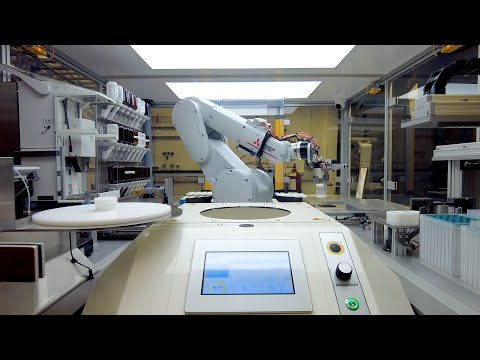

In [42]:
from IPython.display import YouTubeVideo

YouTubeVideo("RLO4sfK37w4",width=640,height=360)